In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

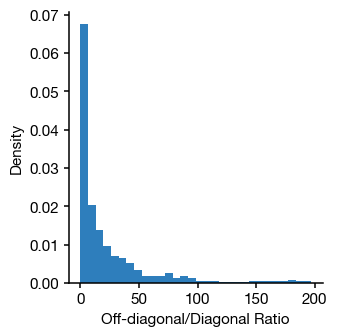

In [ ]:
df = pd.read_csv('./data/kernel_assumptions.csv', header=None)
df.columns = [
    'task',
    'strategy',
    'sampler',
    'model',
    'batch_strategy',
    'size',
    'seed',
    'wcss',
    'diagonal',
    'offdiag',
    'real',
    'nearest',
    'pert-0.98',
    'pert-0.95',
    'pert-0.9'
]

df['ratio'] = df['offdiag'] / df['diagonal']

plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.1
plt.rcParams['font.family'] = 'Helvetica Neue'
fig, ax = plt.subplots(1,1,figsize=(3.5,3.5))
ax.hist(df['ratio'], bins=30, density=True, color=plt.get_cmap('Blues')(0.7))
ax.set_xlabel('Off-diagonal/Diagonal Ratio')
ax.set_ylabel('Density')
ax.tick_params(width=1.1, length=3.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('./figures/offdiagonal.pdf', dpi=500)
plt.show()

Correlation: 0.9959077183504468


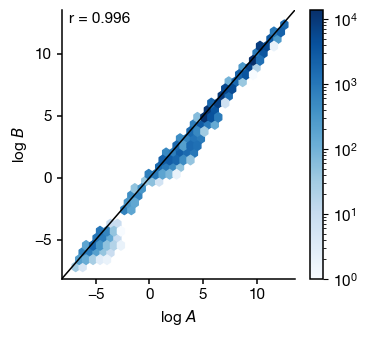

In [3]:
from scipy.stats import spearmanr, pearsonr
corr = pearsonr(np.log(np.abs(df['real'])), np.log(np.abs(df['nearest']))).statistic
print(f'Correlation: {corr}')

plt.rcParams['font.size'] = 11
plt.rcParams['font.family'] = 'Helvetica Neue'
plt.rcParams['axes.linewidth'] = 1.1
fig, ax = plt.subplots(1,1,figsize=(3.8,3.5))
min_val = min(np.min(np.log(np.abs(df['real']))), np.min(np.log(np.abs(df['nearest']))))
max_val = max(np.max(np.log(np.abs(df['real']))), np.max(np.log(np.abs(df['nearest']))))
delta = 0.05 * (max_val - min_val)
min_val -= delta
max_val += delta
ax.plot([min_val, max_val], [min_val, max_val], color='black', zorder=5, linewidth=1.1)
cm = ax.hexbin(np.log(np.abs(df['real'])), np.log(np.abs(df['nearest'])), bins='log', gridsize=30, cmap=plt.get_cmap('Blues'), zorder=4)
ax.set_xlabel('log ' + r'$\it{A}$')
ax.set_ylabel('log ' + r'$\it{B}$')
ax.set_xlim(xmin=min_val, xmax=max_val)
ax.set_ylim(ymin=min_val, ymax=max_val)
ax.tick_params(width=1.1, length=3.3)
ax.set_xticks([-5, 0, 5, 10])
ax.set_yticks([-5, 0, 5, 10])
ax.text(0.03, 0.95, f'r = {corr:.3f}', transform=ax.transAxes)
ax.spines[['top', 'right']].set_visible(False)
fig.colorbar(cm)
plt.tight_layout()
plt.savefig('./figures/nearest.pdf', dpi=500)
plt.show()